<h1> Differential Evolution (DE) </h1>

DE is a population-based optimization algorithm for continuous optimization problems.

**Core idea:**

DE utilizes the difference between solutions to navigate the search space.

In other words:

The distance and direction of movement between individuals in the population generate search information.

DE Core: Mutation Strategy

*DE/rand/1*

Formula:

$V_i=X_{r1}+F(X_{r2}-X_{r3})$

Parameter $F$ is the Differential Weight.

Key DE Parameters

Three main parameters:

1) F — Differential Weight </br>
The extent to which the difference between individuals is utilized.

Typically:</br>
$0.4 \leq F \leq 1$

1. If F is high:</br>
Larger movement</br>
Result:</br>
Greater exploration</br>
Higher probability of traversing/escaping regions</br>
But:</br>
Greater instability

2. If F is low:</br>
Small movement</br>
Result:</br>
Faster convergence</br>
Less exploration


2) CR — Crossover Rate

After mutation, a decision must be made:</br>
How much of the new vector is incorporated into the original solution.

1. Target Vector</br>
2. Donor (Mutant) Vector</br>
3. Trial Vector


3) Population Size

Like GA Larger population:</br>
1. Greater diversity</br>
2. Higher computational cost</br>
3. General DE Structure

For each individual Xi:</br>
1) Select Xr1, Xr2, Xr3</br>
2) Create Mutant Vector</br>
3) Crossover with Xi</br>
4) Create Trial Vector</br>
5) Compare Trial vs Xi</br>
6) Keep better one

One important difference from GA:

In GA:</br>
After generating the new generation:</br>
We had Elites + Offspring.

But in DE:</br>
Each individual competes against its own offspring: </br>

$Trial_i \quad vs \quad X_i$

If better:</br>
It replaces the original.

In other words, DE employs a type of greedy evolutionary replacement.

Unlike the GA we used for the Knapsack problem, DE is suitable for continuous optimization problems.

In [12]:
import numpy as np
import matplotlib.pyplot as plt

from problems.benchmark_functions import sphere_function
from src.DE import (
    initialize_population,
    mutation,
    boundary_handling,
    mutation_with_boundary,
    crossover,
    selection,
    differential_evolution
)

<h3> Step 1: Sphere Function </h3>

$F(x)=∑_(i=1) nx_i^2 $

In [2]:
x = np.array(
    [2, -3, 1]
)

sphere_function(x)

14

<h3> Step 2: Initial Population </h3>

In [3]:
population = initialize_population(
    population_size=5,
    dimension=2,
    bounds=[
        (-5,5),
        (-5,5)
    ]
)

population

array([[-4.22271436, -3.51567332],
       [-3.29053662,  2.09663603],
       [-2.13017697, -3.85615118],
       [ 0.69736563, -0.19955162],
       [ 2.23043115, -4.44019845]])

<h3> Step 3: Mutation (DE/rand/1) </h3>

This section is the heart of Differential Evolution.

In GA, mutation was a random change to the genes.

However, in DE, mutation is completely different. </br>
DE utilizes the distance and direction of movement between individuals in the population.

In [4]:
population = np.array(
    [
        [5,2],
        [3,1],
        [1,4],
        [2,5],
        [-1,3],
    ]
)

mutant = mutation(
    population,
    target_index=0,
    F=0.5,
)

print(mutant)

[-1.  5.]


<h3> Step 4: Boundary Handling </h3>

Methods:

1. Clipping
2. Reflection
3. Random Reinitialization

In [5]:
vector = np.array(
    [
        8,
        -12,
        3
    ]
)

bounds = [
    (-5,5),
    (-10,10),
    (-2,2),
]

boundary_handling(
    vector,
    bounds,
)

array([  5, -10,   2])

An important conceptual point:

In GA:

Mutation itself was the driver of change.

However, in DE:

Mutation:

Acts as the driver of directed movement within the solution space.

Therefore, boundary handling is more critical in DE, as the movements involved can be large.

In [6]:
mutant = mutation_with_boundary(
    population,
    target_index=0,
    F=0.8,
    bounds=[
        (-5,5),
        (-5,5)
    ],
)

print(mutant)

[-0.2 -0.2]


<h3> Step 5: Crossover (Binomial Crossover) </h3>

In [7]:
target = np.array(
    [1,2,3,4]
)

mutant = np.array(
    [9,8,7,6]
)

trial = crossover(
    target,
    mutant,
    CR=0.5,
)

print(trial)

[1 8 3 6]


<h3> Step 6: Selection </h3>

Since we have the Sphere:

Objective:

Minimize

Therefore:

Lower is better.

In [8]:
target = np.array(
    [3,3]
)

trial = np.array(
    [1,1]
)

winner = selection(
    target,
    trial,
    sphere_function,
)

print(winner)

[1 1]


<h3> Step 6: Complete Differential Evolution Algorithm </h3>

An important point before writing the loop:

In DE, there is no longer such a thing as:</br>
elite_ratio</br>
This is because the selection process is inherently elitist.

In other words:</br>
An individual is replaced only if the replacement is better.

Thus, DE naturally:</br>
Retains good solutions.</br>
Discards bad solutions.

In [9]:
bounds = [
    (-5,5),
    (-5,5)
]

result = differential_evolution(
    sphere_function,
    bounds,
    population_size=50,
    generations=200,
    F=0.5,
    CR=0.7,
)

In [10]:
print("Solution:")
print(result["solution"])

print("\n Fitness:")
print(result["fitness"])

print("\n History:")
print(result["history"])

print("\n Solution History")
print(
    result["solution_history"][:5]
)

Solution:
[6.96620639e-27 2.55563374e-27]

 Fitness:
5.505929531357903e-53

 History:
[0.39583679051423665, 0.39583679051423665, 0.3554300512846339, 0.003595533475555137, 0.00208563098510744, 0.00208563098510744, 0.00208563098510744, 0.00208563098510744, 0.00208563098510744, 6.098105042315236e-05, 6.098105042315236e-05, 6.098105042315236e-05, 6.098105042315236e-05, 6.098105042315236e-05, 1.4325088451144243e-06, 1.4325088451144243e-06, 1.4325088451144243e-06, 1.4325088451144243e-06, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 4.1143345100952866e-10, 1.4143562689407888e-11, 1.4143562689407888e-11, 8.929013087800336e-12, 8.929013087800336e-12, 8.929013087

<h3> Step 7: Analysis </h3>

<h3> Step 7.1: DE Convergence Curve </h3>

As with GAs, the first thing to examine is how the algorithm moves toward a better solution over successive generations.

Objective

To examine:

Convergence speed
Exploration vs. exploitation behavior
Whether DE gets stuck prematurely

In [13]:
history = result["history"]

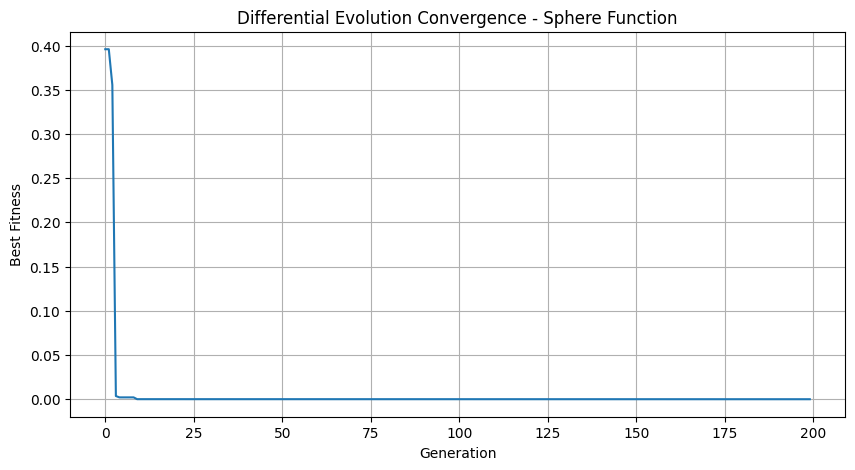

In [14]:
plt.figure(figsize=(10,5))

plt.plot(
    history
)
plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "Differential Evolution Convergence - Sphere Function"
)

plt.grid()
plt.show()

## DE Convergence Analysis on Sphere Function

The convergence behavior of Differential Evolution was evaluated on the Sphere benchmark function.

### Observation

The algorithm shows a rapid reduction in fitness during the early generations, indicating effective exploration of the search space.

After reaching a region close to the optimum, the improvement rate decreases and the algorithm performs fine-grained exploitation around the solution.

The fitness value approaches zero, which confirms that DE successfully converges toward the global optimum of the Sphere function:

$x^*=[0,0], \quad f(x^*)=0$

### Conclusion

The results demonstrate the exploration-exploitation behavior of DE. Large vector differences in early generations allow broad search, while reduced differences between individuals near the optimum enable accurate convergence.